In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import h5py

import os
import sys
print(os.getpid())
sys.path.append(os.path.abspath("./"))
%cd ../../

import pylib.mix as mix

import stepanoff

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

17121
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/init_mod"
for i in range(100):
    plt.close()

In [3]:
mix.reload_module(mix)
mix.reload_module(stepanoff)

# --- Parameters for temporal and spatial grids ---
# n_half_ = 9
# dt_, Nt_ = 0.001, 2000   # total time interval is dt_ * Nt_

n_half_ = 5
dt_, Nt_ = 0.1, 10   # total time interval is dt_ * Nt_

# --- other parameters ---
kappa_ = 1.
flag_cut_ = True
alpha_ = np.sqrt(20.)

# --- spatial grid ---
n_ = n_half_ + 1
N_half_ = 1 << n_half_
N_ = 2 * N_half_ + int(not flag_cut_)
x_ = np.linspace(0., 2.*np.pi, N_)

# --- initial conditions ---
init_2d_ = stepanoff.f_init_2d(kappa_, x_, N_)

# --- unitary operators ---
diag_U_M1_  = stepanoff.create_diag_matrix(dt_, N_half_, alpha_, "M1", flag_cut_)
diag_U_M2_  = stepanoff.create_diag_matrix(dt_, N_half_, alpha_, "M2", flag_cut_)

In [ ]:
# -------------------------------------------------------------------
# --- Classical simulations in real space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_dopri_new_ = stepanoff.get_Dopri_classical_simulations(
    dt_, Nt_, x_,
    alpha_, kappa_,
    path_save = path_save_,
    prefix = "new_", 
    flag_plot = False
)

--- Looking for the file: new_Stepanoff_data_k1.0_a4.472_n6.hdf5 in the path ./jupyter-notebooks/Stepanoff/results/
--- Loading data ---
Reading the coefficients from:
 ./jupyter-notebooks/Stepanoff/results/new_Stepanoff_data_k1.0_a4.472_n6.hdf5

Take the Dopri simulation at t = 1


In [5]:
# -----------------------------------------------------------------
# --- Computation ---
# -----------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_mix_mod_, y_cl_mix_ = stepanoff.computation_in_real_and_fourier(
    dt_, Nt_, x_,
    diag_U_M1_, diag_U_M2_, init_2d_,
    flag_plot = False
)

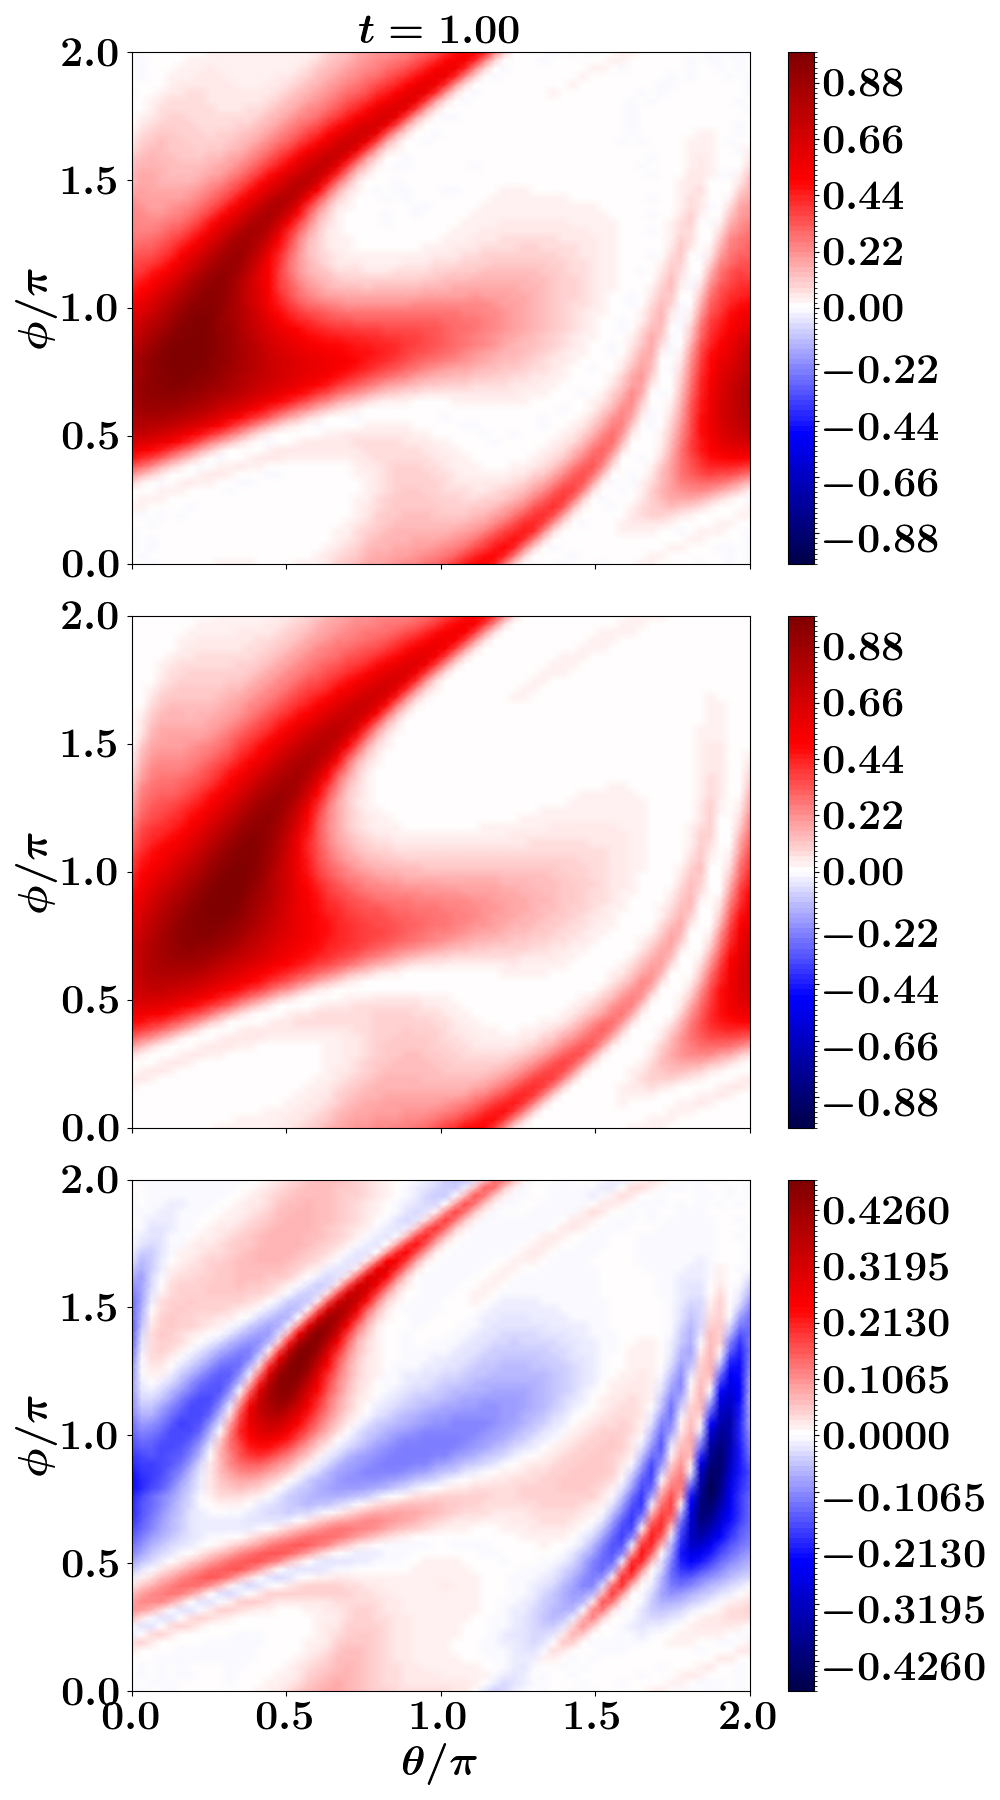

max. abs. err : 4.841e-01


In [ ]:
# -------------------------------------------------------------------
# --- Compare classical simulations in real and mix spaces ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def compare_classical(y_cl_mix, y_cl_dopri, flag_plot = False):
    # --- Error ---
    err_cl = y_cl_dopri - y_cl_mix
    max_abs_err_cl = np.max(np.abs(err_cl))
    
    # --- Plotting ---
    if flag_plot:
        X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
        fig1, axs = plt.subplots(3, 1, figsize=(10,18))
        stepanoff.plot_2D_subplot(
            axs[0], fig1, X, Y, y_cl_mix,  
            str_title="$" + "t={:0.2f}".format(Nt_*dt_) + "$", 
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[1], fig1, X, Y, y_cl_dopri,  
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[2], fig1, X, Y, err_cl,   
            label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
        )
        plt.tight_layout()
        plt.show()

    # --- Printing ---
    print("max. abs. err : {:0.3e}".format(max_abs_err_cl))
    return
# -------------------------------------------------------------------
compare_classical(y_cl_mix_, y_cl_dopri_new_, flag_plot = True)

In [ ]:
# -------------------------------------------------------------------
# --- Summation in modified coordinates ---
# -------------------------------------------------------------------
def integrate_mod_(psi_mod):
    Nx = np.shape(psi_mod)[0]

    psi_mod_work = psi_mod / np.max(np.abs(psi_mod))

    res_v = 0.
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            res_v += psi_mod_work[i_theta, i_phi] * np.cos(i_phi)
    res_v /= Nx**2

    print("res: {:0.3e}".format(res_v))

    return res_v
# -----------------------------------------------------
res_v_ = integrate_mod_(y_cl_mix_mod_)

res: 8.629e-04


In [64]:
# ---------------------------------------------------------------------------
# --- Scan of the difference between classical simulations ---
# ---------------------------------------------------------------------------
def scan_dt():
    def save_one(x, y, dt_loc, t_loc, str_v):
        str_dt = "dt{:0.3f}".format(dt_loc)
        str_t = "t{:d}".format(int(t_loc))

        x = np.array(x)
        y = np.array(y)

        str_file = "{:s}_{:s}_{:s}".format(str_v, str_t, str_dt)

        # print("\n\n-----------------------------------------------")
        # print(str_file)
        # print("-----------------------------------------------")
        # print("nx: ", x)
        # print("err: ", end="")
        # mix.print_array(y, ff = [14,4,"e"])


        mix.save_dat_plot_1d_file(
            path_save_ + "/scan_{:s}.dat".format(str_file), 
            x, y
        )
        return
    # ------------------------------------------------------------------
    err_array_nx_t = {}

    dt_array = np.array([0.1, 0.01, 0.001])
    nx_arr   = np.array([6, 7, 8, 9, 10], dtype= int)

    # -----------------------------------------------------------
    nx = 6
    err_loc = {}

    t = 1.
    err_array = [4.841e-01, 2.286e-01, 2.130e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 2.
    err_array = [6.905e-01, 6.799e-01, 6.793e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 4.
    err_array = [1.093e+00, 9.471e-01, 9.504e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    err_array_nx_t["nx{:d}".format(nx)] = err_loc

    # -----------------------------------------------------------
    nx = 7
    err_loc = {}

    t = 1.
    err_array = [4.657e-01, 1.354e-01, 1.106e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 2.
    err_array = [6.720e-01, 3.941e-01, 3.939e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 4.
    err_array = [1.241e+00, 8.262e-01, 8.269e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    err_array_nx_t["nx{:d}".format(nx)] = err_loc

    # -----------------------------------------------------------
    nx = 8
    err_loc = {}

    t = 1.
    err_array = [4.649e-01, 8.551e-02, 5.568e-02]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 2.
    err_array = [6.580e-01, 2.064e-01, 2.061e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 4.
    err_array = [1.158e+00, 9.109e-01, 7.891e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    err_array_nx_t["nx{:d}".format(nx)] = err_loc

    # -----------------------------------------------------------
    nx = 9
    err_loc = {}

    t = 1.
    err_array = [4.648e-01, 6.678e-02, 2.908e-02]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 2.
    err_array = [6.505e-01, 1.204e-01, 1.042e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 4.
    err_array = [1.000e+00, 8.504e-01, 5.501e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    err_array_nx_t["nx{:d}".format(nx)] = err_loc

    # -----------------------------------------------------------
    nx = 10
    err_loc = {}

    t = 1.
    err_array = [4.644e-01, 6.706e-02, 1.605e-02]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 2.
    err_array = [6.466e-01, 1.065e-01, 5.233e-02]
    err_loc["t{:d}".format(int(t))] = err_array

    t = 4.
    err_array = [9.944e-01, 8.464e-01, 2.983e-01]
    err_loc["t{:d}".format(int(t))] = err_array

    err_array_nx_t["nx{:d}".format(nx)] = err_loc

    # -----------------------------------------------------------
    # --- Scaling: dep. on nx for t = 1 ---
    # -----------------------------------------------------------
    del t, nx, err_array, err_loc
    t_array = [1., 2., 4.]

    for ii_t in range(len(t_array)):
        t_1 = t_array[ii_t]
        for ii_dt in range(len(dt_array)):
            err_scan = np.zeros(len(nx_arr))
            for ii_x in range(len(nx_arr)):
                err_scan[ii_x] = err_array_nx_t["nx{:d}".format(nx_arr[ii_x])]["t{:d}".format(int(t_1))][ii_dt]
            save_one(nx_arr, err_scan, dt_array[ii_dt], t_1, "CL_err_nx")

    return err_array_nx_t
# --------------------------------------------------------------
err_array_nx_t_ = scan_dt()

write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t1_dt0.100.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t1_dt0.010.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t1_dt0.001.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t2_dt0.100.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t2_dt0.010.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t2_dt0.001.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t4_dt0.100.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t4_dt0.010.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scan_CL_err_nx_t4_dt0.001.dat
